In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Networks 
## CNN
- multi-class - Fashion MNIST dataset (all 60000 images)

<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com"/>

In [2]:
###-----------------
### Import Libraries
###-----------------

###-----------------
### Import libraries
###-----------------
from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import accuracy_score, classification_report  # Import function to calculate various metric

from utils.helper import fn_plot_confusion_matrix, fn_plot_tf_hist

import tensorflow as tf

In [3]:
# Some basic parameters

inpDir = Path('..') / '..' / 'input'
outDir = Path('..') / 'output'
subDir = 'fashion_MNIST' # location of the images
modelDir = Path('..') / 'models'
altName = 'tf_fashion_all'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE)
tf.random.set_seed(seed=RANDOM_STATE)

EPOCHS = 10 # number of cycles to run
ALPHA = 0.001 # learning rate
BATCH_SIZE = 32


# Set parameters for decoration of plots
params = {'legend.fontsize' : 'large',
          'figure.figsize'  : (9,9),
          'axes.labelsize'  : 'x-large',
          'axes.titlesize'  :'x-large',
          'xtick.labelsize' :'large',
          'ytick.labelsize' :'large',
         }

plt.rcParams.update(params) # update rcParams
CMAP = plt.cm.coolwarm
plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

In [4]:
physical_devices = tf.config.list_logical_devices('GPU')

if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    
print(tf.__version__, physical_devices)

2.21.0 []


## Helper Functions

In [5]:
def fn_plot_labels(train_df, test_df):
    plt.figure(figsize=(15,5))
    plt.subplots(1,2,1)
    
    ax = train_df['label'].value_counts().plot(kind='bar',
                                               title='Train',
                                               color='DarkBlue',
                                               alpha=0.7)
    
    plt.subplots(1,2,2)
    ax = test_df['label'].value_counts().plot(kind='bar',
                                              title='Test',
                                              color = 'Orange',
                                              alpha = 0.7)


## Load Fashion MNIST dataset

This guide uses the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset which contains 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels), as seen here:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Fashion MNIST is intended as a drop-in replacement for the classic [MNIST](http://yann.lecun.com/exdb/mnist/) dataset—often used as the "Hello, World" of machine learning programs for computer vision. The MNIST dataset contains images of handwritten digits (0, 1, 2, etc.) in a format identical to that of the articles of clothing you'll use here.

This guide uses Fashion MNIST for variety, and because it's a slightly more challenging problem than regular MNIST. Both datasets are relatively small and are used to verify that an algorithm works as expected. They're good starting points to test and debug code.

Here, 60,000 images are used to train the network and 10,000 images to evaluate how accurately the network learned to classify images. You can access the Fashion MNIST directly from TensorFlow. Import and [load the Fashion MNIST data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data) directly from TensorFlow:

In [6]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [7]:


train_df = pd.read_csv('D:/Deep_Learning/SharedData/fashion-mnist_train.csv', header = 0)
test_df = pd.read_csv('D:/Deep_Learning/SharedData/fashion-mnist_test.csv', header = 0)


In [11]:
def split_feature_label(row_dict):
    # Pop out the label tensor using its column name
    label = row_dict.pop('label') 
    
    # The remaining keys in the dictionary are your pixel features
    # features = row_dict
    
    
    # Stack the 784 pixel values into a single tensor and reshape to (28, 28)
    features = tf.cast(tf.stack(list(row_dict.values())), tf.float32)
    features = tf.reshape(features, (28, 28))  # or (28, 28, 1) for CNN
    
    
    
    return features, label

In [12]:
tmp_ds = tf.data.Dataset.from_tensor_slices(dict(train_df))
train_ds = tmp_ds.map(split_feature_label)

train_ds = train_ds.cache()
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

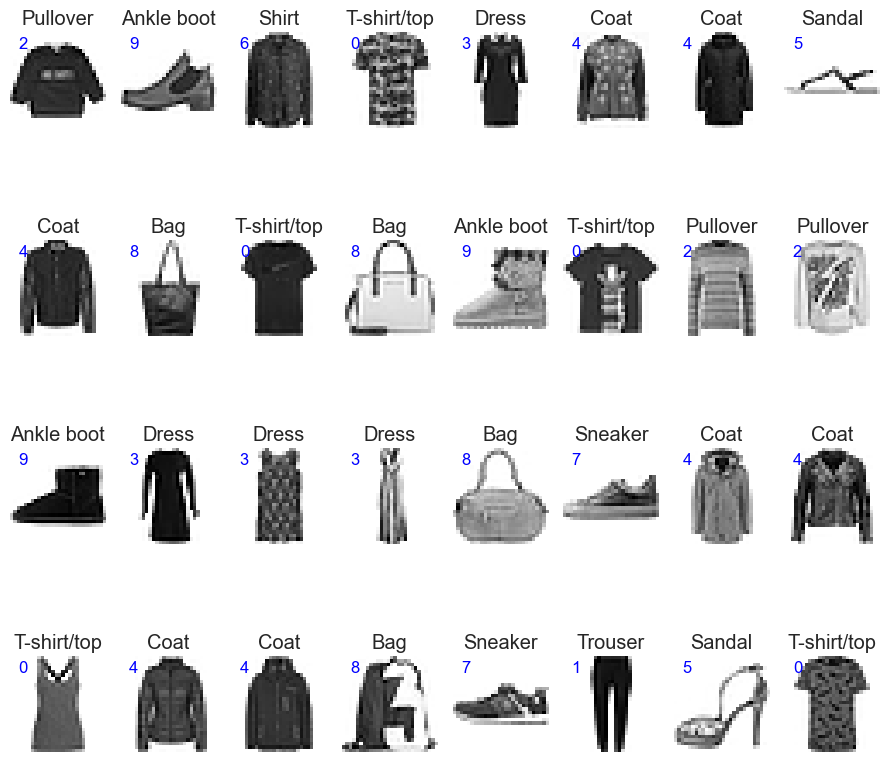

In [13]:
for images, labels in train_ds.take(1):
    for i in range(BATCH_SIZE):
        plt.subplot(BATCH_SIZE//8, 8, i+1)
        plt.grid(False)
        plt.imshow(images[i].numpy().astype('uint8'), cmap=plt.cm.binary)
        plt.title(class_names[labels[i].numpy()])
        plt.text(2, 4, labels[i].numpy(), c='b', fontsize=12)
        plt.axis('off')
plt.tight_layout()

In [14]:

tmp_ds = tf.data.Dataset.from_tensor_slices(dict(test_df))
test_ds = tmp_ds.map(split_feature_label)

test_ds = test_ds.cache()
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

## Demos
### Normalization Layer

In [15]:
normnalization_layer = tf.keras.layers.Rescaling(1/255.)

images, labels = next(iter(train_ds))

img =images[0].numpy()
print(f'Original: Min:{img.min()}, Max: {img.max()}, Std: {img.std()}')

norm_ds = train_ds.map(lambda x, y: (normnalization_layer(x), y))

images, labels = next(iter(norm_ds))

img =images[0].numpy()
print(f'Normalized: Min:{img.min()}, Max: {img.max()}, Std: {img.std()}')

Original: Min:0.0, Max: 255.0, Std: 103.16875457763672
Normalized: Min:0.0, Max: 1.0, Std: 0.4045833945274353


<Axes: >

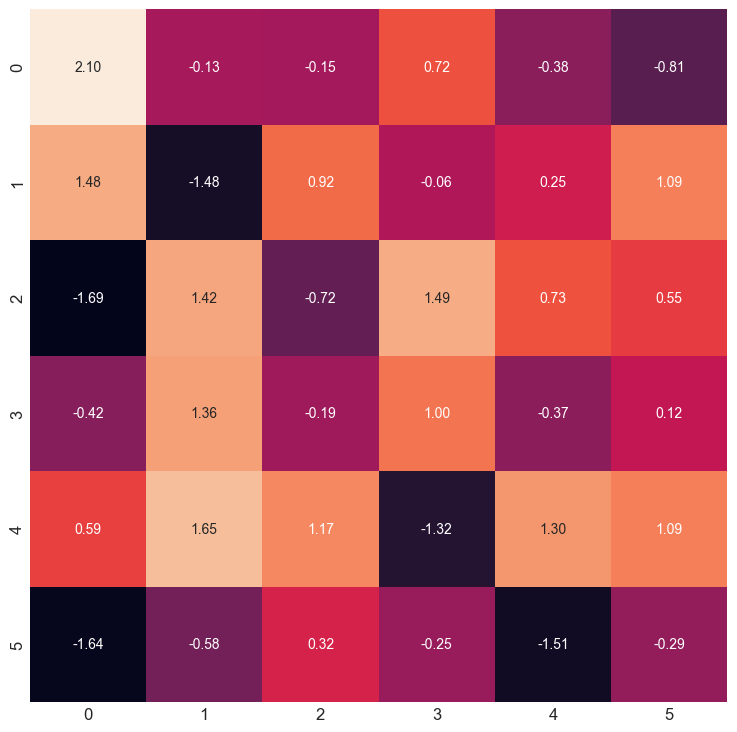

In [16]:
input_shape = (1,6,6,1)

X =tf.random.normal(input_shape)

sns.heatmap(X.numpy()[0, :, :, 0], annot = True, fmt = '.2f', cbar=False)

<Axes: >

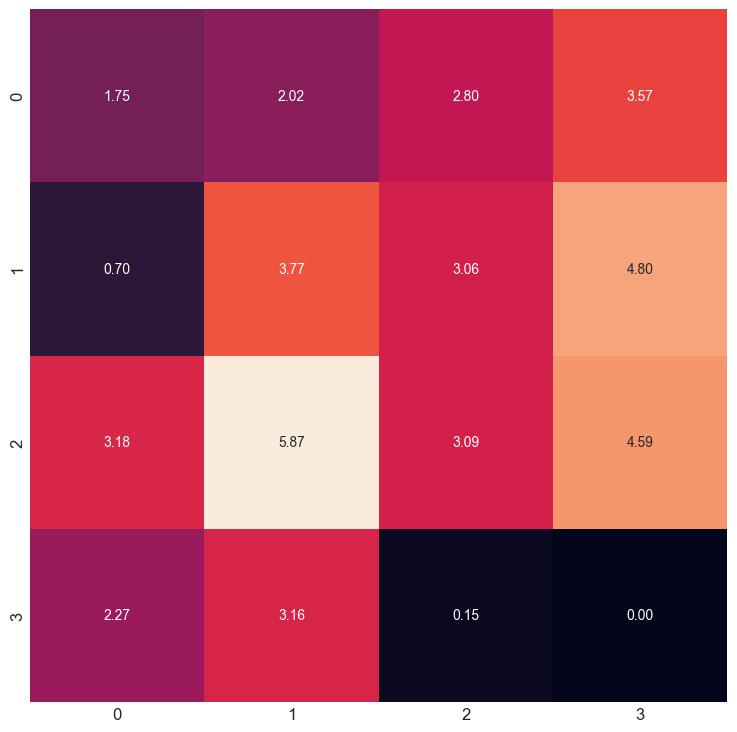

In [17]:
y = tf.keras.layers.Conv2D(1, 3, 
                           kernel_initializer=tf.constant_initializer(1.0), 
                           use_bias=False,
                           activation= 'relu')(X)

sns.heatmap(y.numpy()[0, :, :, 0], annot = True, fmt = '.2f', cbar=False)

<Axes: >

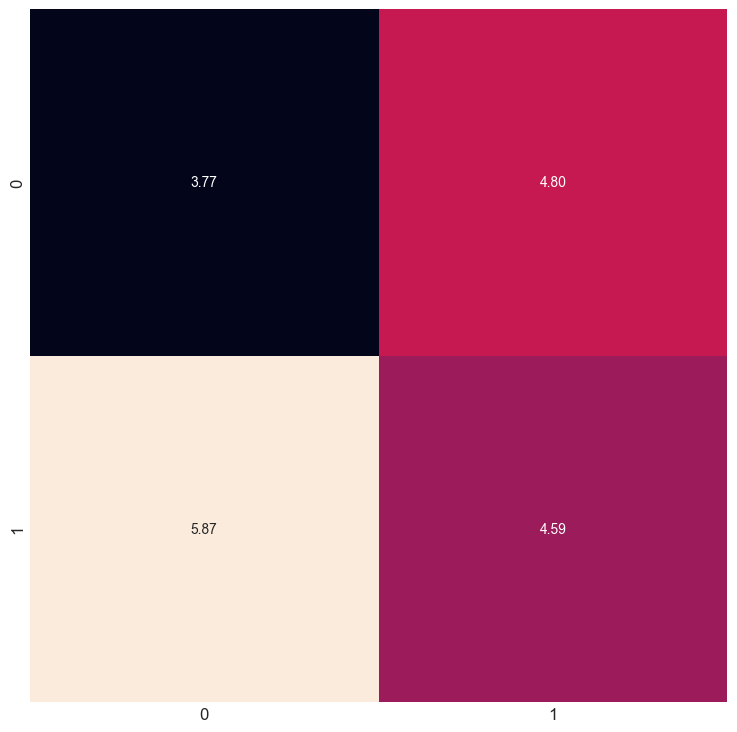

In [18]:
max_pool_2d = tf.keras.layers.MaxPool2D()

z = max_pool_2d(y)
sns.heatmap(z.numpy()[0, :, :, 0], annot = True, fmt = '.2f', cbar=False)

# Define Model

In [ ]:
krnal_init = tf.keras.initializers.GlorotUniform(seed=RANDOM_STATE)

input_shape = (28, 28, 1)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=input_shape))
model.add(tf.keras.layers.Rescaling(1./255.))

# Set 1
model.add(tf.keras.layers.Conv2D(32, (3,3), 
                                 kernel_initializer = krnal_init,
                                 padding= 'same',
                                 activation= 'relu'))    #(28 x 28 x 32)

model.add(tf.keras.layers.MaxPool2D())   # (14 x 14 x 32)

# Set 2
model.add(tf.keras.layers.Conv2D(64, (3,3), 
                                 kernel_initializer = krnal_init,
                                 activation= 'relu'))    # (12 x 12 x 64)

model.add(tf.keras.layers.MaxPool2D())   # (6 x 6 x 64)

# Set 3
model.add(tf.keras.layers.Conv2D(128, (3,3), 
                                 kernel_initializer = krnal_init,
                                 activation= 'relu'))    #(4 x 4 x 128)

### Head
model.add(tf.keras.layers.Flatten())   # (2048)

# Dense 1
model.add(tf.keras.layers.Dense(128,  
                                 kernel_initializer = krnal_init,
                                 activation= 'relu'))    #(128)

# Dense 2
model.add(tf.keras.layers.Dense(10,  
                                 kernel_initializer = krnal_init))  #(10)

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,234 (1.36 MB)

 Trainable params: 356,234 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

None


In [20]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)

model.compile(optimizer=optimizer,
              loss=loss_fn,
              metrics=['accuracy'])

In [21]:
history = model.fit(train_ds,
                    validation_data=test_ds,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 22ms/step - accuracy: 0.8456 - loss: 0.4225 - val_accuracy: 0.8853 - val_loss: 0.3097
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9000 - loss: 0.2720 - val_accuracy: 0.9009 - val_loss: 0.2645
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9174 - loss: 0.2247 - val_accuracy: 0.9081 - val_loss: 0.2462
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9316 - loss: 0.1877 - val_accuracy: 0.9156 - val_loss: 0.2377
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9422 - loss: 0.1573 - val_accuracy: 0.9145 - val_loss: 0.2493
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9525 - loss: 0.1306 - val_accuracy: 0.9182 - val_loss: 0.2631
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9576 - loss: 0.1129 - val_accuracy: 0.9134 - val_loss: 0.3077
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9643 -

In [22]:
loss_df = pd.DataFrame(history.history)
loss_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.845550,0.422463,0.8853,0.309667
1,0.899983,0.272018,0.9009,0.264460
2,0.917383,0.224711,0.9081,0.246199
3,0.931567,0.187700,0.9156,0.237675
4,0.942167,0.157321,0.9145,0.249320


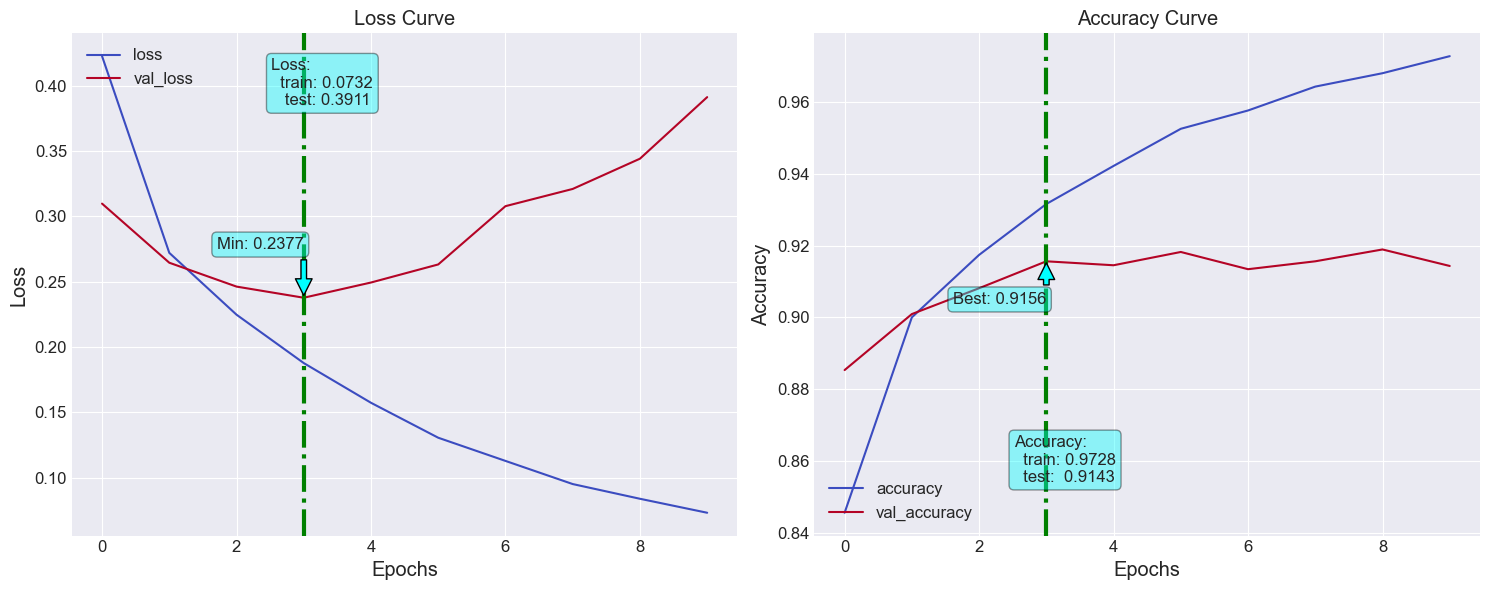

In [23]:
fn_plot_tf_hist(loss_df)

## Prediction on Train dataset

In [24]:
y_true, y_pred = [], []

for features, labels in train_ds:
    pred = model(features, training=False)
    pred = pred.numpy().argmax(axis=1)
    y_pred.append(pred)
    y_true.append(labels.numpy())
    
y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)

accuracy_score(y_true, y_pred)

0.9551

In [26]:
print(classification_report(y_true, y_pred, target_names=list(class_names)))

              precision    recall  f1-score   support

 T-shirt/top       0.93      0.95      0.94      6000
     Trouser       1.00      1.00      1.00      6000
    Pullover       0.95      0.90      0.92      6000
       Dress       0.94      0.98      0.96      6000
        Coat       0.85      0.97      0.91      6000
      Sandal       0.99      1.00      0.99      6000
       Shirt       0.94      0.80      0.87      6000
     Sneaker       1.00      0.96      0.98      6000
         Bag       1.00      0.99      1.00      6000
  Ankle boot       0.97      1.00      0.98      6000

    accuracy                           0.96     60000
   macro avg       0.96      0.96      0.95     60000
weighted avg       0.96      0.96      0.95     60000



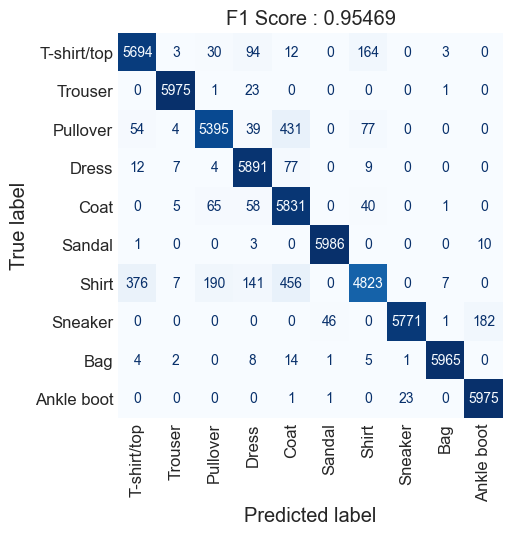

In [27]:
fn_plot_confusion_matrix( y_true, y_pred, labels=class_names)

## Prediction on Test dataset

In [28]:
y_true, y_pred = [], []

for features, labels in test_ds:
    pred = model(features, training=False)
    pred = pred.numpy().argmax(axis=1)
    y_pred.append(pred)
    y_true.append(labels.numpy())
    
y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)

accuracy_score(y_true, y_pred)

0.9143

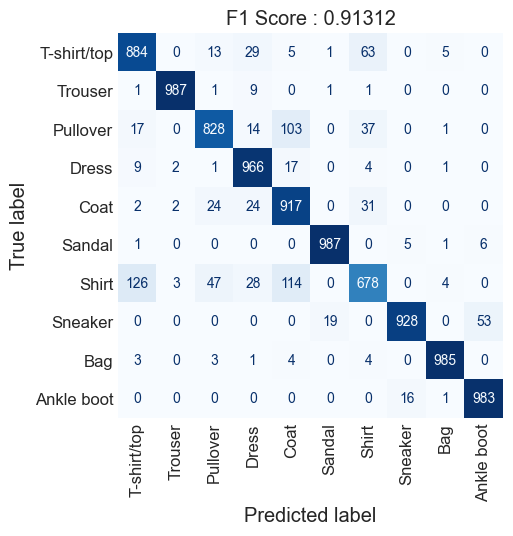

In [29]:
fn_plot_confusion_matrix( y_true, y_pred, labels=class_names)